In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
from simulators import ContextManager, NestedModelFamily
from simulators.benchmarks import DDM, RDM, CDM

### Metas

In [50]:
intrinsic_params = ["v", "a", "tau", "s_v", "s_tau", "decay"]
num_obs = 2000
num_configs = 6
num_regressors = 4
p_free = 0.5

### Priors

In [51]:
# Priors: intercept vs slope samplers per intrinsic
priors = {
    "v":     {"intercept": lambda: np.random.gamma(3.0, 0.8),
              "slope":     lambda: np.random.normal(0.0, 3.0)},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: np.random.normal(0.0, 1.0)},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

### Context Manager

In [52]:
cm = ContextManager()  # not used in full-regression path

family = NestedModelFamily(
    name="DDM",
    model=DDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=intrinsic_params,
)

In [53]:
out = family.sample(
    design_config=None,
    num_obs=num_obs,
    num_regressors=num_regressors,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a"},
        intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},  # different mask each run, reproducible
    )
)

In [54]:
out

{'model_name': 'DDM',
 'design_config': {'1': ['v', 'a', 'tau', 's_v'],
  'u_1': ['v'],
  'u_2': ['a'],
  'u_3': ['a']},
 'design_matrix': array([[1.        , 0.6378816 , 1.        , 0.33746108],
        [1.        , 0.56711674, 1.        , 0.2843882 ],
        [1.        , 0.7489675 , 1.        , 0.37583873],
        ...,
        [1.        , 0.2859899 , 0.        , 0.8290358 ],
        [1.        , 0.39323664, 0.        , 0.5509427 ],
        [1.        , 0.05916835, 0.        , 0.1211623 ]],
       shape=(2000, 4), dtype=float32),
 'param_mask': array([[1., 1., 1., 1., 1., 1.],
        [1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.]], dtype=float32),
 'param_matrix': array([[2.11606173, 2.97891937, 0.86880357, 0.24892135, 0.25801007,
         0.31618977],
        [1.81070999, 0.        , 0.        , 0.        , 0.        ,
         0.        ],
        [0.        , 0.58057209, 0.        , 0.        , 0.        ,
         0.        ],
    

In [55]:
design_matrix     = out["design_matrix"]
parameter_mask    = out["param_mask"]
parameter_matrix  = out["param_matrix"]
params_for_model  = out["param_samples"]
sim_data          = out["sim_trials"]

In [56]:
design_matrix

array([[1.        , 0.6378816 , 1.        , 0.33746108],
       [1.        , 0.56711674, 1.        , 0.2843882 ],
       [1.        , 0.7489675 , 1.        , 0.37583873],
       ...,
       [1.        , 0.2859899 , 0.        , 0.8290358 ],
       [1.        , 0.39323664, 0.        , 0.5509427 ],
       [1.        , 0.05916835, 0.        , 0.1211623 ]],
      shape=(2000, 4), dtype=float32)

In [57]:
parameter_mask

array([[1., 1., 1., 1., 1., 1.],
       [1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.]], dtype=float32)

In [58]:
parameter_matrix

array([[2.11606173, 2.97891937, 0.86880357, 0.24892135, 0.25801007,
        0.31618977],
       [1.81070999, 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.58057209, 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.68324032, 0.        , 0.        , 0.        ,
        0.        ]])

In [59]:
sim_data

{'rts': array([1.2298188 , 1.4011446 , 0.79241633, ..., 0.97449905, 0.8762146 ,
        0.8449712 ], shape=(2000,), dtype=float32),
 'choices': array([1., 1., 1., ..., 1., 1., 1.], shape=(2000,), dtype=float32)}

In [60]:
print("design_matrix shape        :", design_matrix.shape)        # (N, K)
print("parameter_mask shape       :", parameter_mask.shape)       # (K, M)
print("parameter_matrix shape     :", parameter_matrix.shape)     # (K, M)

design_matrix shape        : (2000, 4)
parameter_mask shape       : (4, 6)
parameter_matrix shape     : (4, 6)


In [61]:
design_matrix

array([[1.        , 0.6378816 , 1.        , 0.33746108],
       [1.        , 0.56711674, 1.        , 0.2843882 ],
       [1.        , 0.7489675 , 1.        , 0.37583873],
       ...,
       [1.        , 0.2859899 , 0.        , 0.8290358 ],
       [1.        , 0.39323664, 0.        , 0.5509427 ],
       [1.        , 0.05916835, 0.        , 0.1211623 ]],
      shape=(2000, 4), dtype=float32)

In [62]:
intrinsic_values_matrix = (design_matrix @ parameter_matrix).astype(np.float32)
assert intrinsic_values_matrix.shape == (num_obs, len(intrinsic_params))

In [63]:
col_idx = {name: j for j, name in enumerate(intrinsic_params)}
v_arr = params_for_model["v"]
a_arr = params_for_model["a"]
print(col_idx, v_arr, a_arr)

{'v': 0, 'a': 1, 'tau': 2, 's_v': 3, 's_tau': 4, 'decay': 5} [2.6151955 2.4920487 2.8096533 ... 2.0100963 2.1923952 1.6328446] [3.119254  3.0838082 3.1449032 ... 2.880653  2.6965008 2.4143007]


In [64]:
intercepts = out["param_samples"].get("_intercepts", {})
print("Intercepts:", {k: round(v, 4) for k, v in intercepts.items()})

Intercepts: {}


In [65]:
rts = sim_data["rts"]
choices = sim_data["choices"]
print("Simulated RTs:", np.nanmin(rts[rts>0]), "→", np.nanmax(rts))
print("Choice rate (mean):", np.mean(choices))

Simulated RTs: 0.55837846 → 3.2516236
Choice rate (mean): 1.0


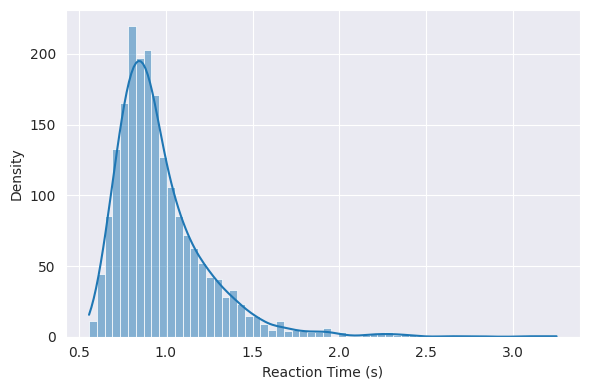

In [66]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(rts[rts > 0], bins=60, kde=True, ax=ax)
ax.set_xlabel("Reaction Time (s)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

### Testing multiple batches

In [85]:
runs = []
for k in range(num_configs):
    res = family.sample(
        design_config=None,                 # AUTO: build_random_parameter_mask + mask_to_design_config
        num_obs=num_obs,
        num_regressors=num_regressors,
        mask_randomizer_kwargs=dict(
            mandatory_intrinsics={"v", "a", "tau"},
            intercept_only_intrinsics={"s_tau", "s_v", "decay"},
        ),
    )
    runs.append(res)

In [86]:
def check_run(res):
    dm, pm = res["design_matrix"], res["param_matrix"]
    assert dm.shape == (num_obs, num_regressors)
    rts = res["sim_trials"]["rts"]; choices = res["sim_trials"]["choices"]
    assert rts.shape == (num_obs,) and choices.shape == (num_obs,)
    assert np.isfinite(rts).all()  # if timeouts exist they’ll be -1.0; adjust if you want to allow them
    return rts

all_rts = [check_run(r) for r in runs]
print(f"OK: ran {len(runs)} configs × {num_obs} trials with AUTO full-regression.")

OK: ran 6 configs × 2000 trials with AUTO full-regression.


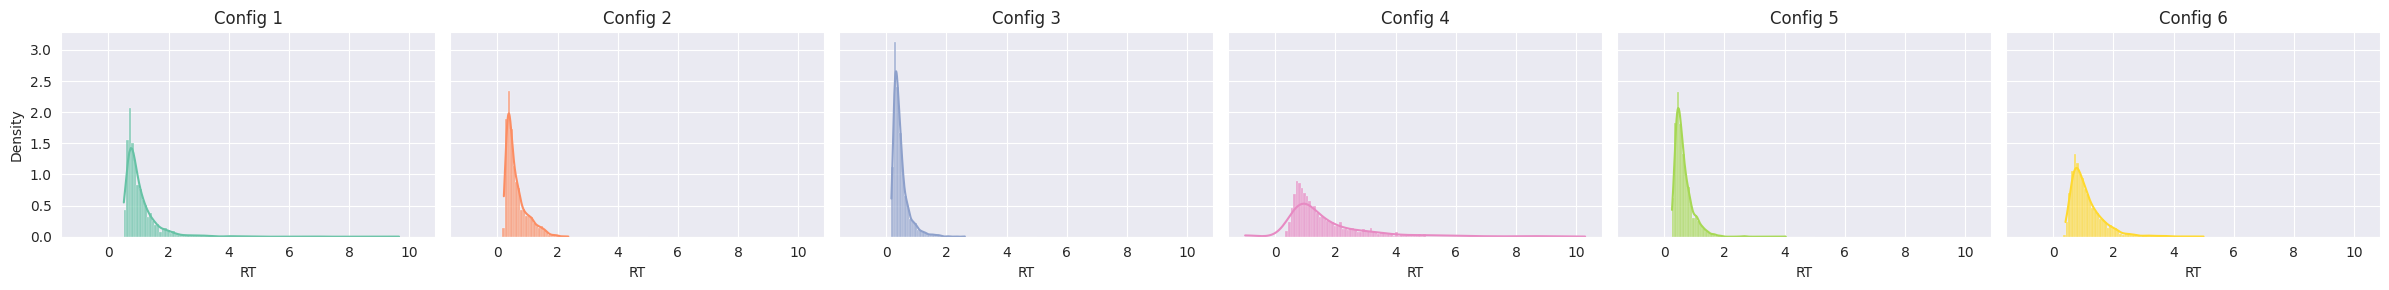

In [87]:
fig, axes = plt.subplots(1, num_configs, figsize=(4*num_configs, 3), sharex=True, sharey=True)
bins = np.linspace(0.0, 5.0, 60)
palette = sns.color_palette("Set2", n_colors=num_configs)

for ax, rts, idx in zip(np.atleast_1d(axes), all_rts, range(num_configs)):
    sns.histplot(rts, bins=bins, stat="density", kde=True, color=palette[idx], alpha=0.7, ax=ax)
    ax.set_title(f"Config {idx+1}")
    ax.set_xlabel("RT")
    ax.set_ylabel("Density")

plt.tight_layout()

### Batch sampling

In [111]:
samples = family.batch_sample(
    batch_size=6,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a", "tau", "s_tau", "s_v"},
        intercept_only_intrinsics={"decay"},
    ),
    min_num_obs=1000,
    max_num_obs=5000
)

4625 10
4625 10
4625 10
4625 10
4625 10
4625 10


In [112]:
samples

{'model_names': ['DDM', 'DDM', 'DDM', 'DDM', 'DDM', 'DDM'],
 'design_configs': [{'1': ['v', 'a', 'tau', 's_v', 's_tau', 'decay'],
   'u_1': ['tau', 's_tau'],
   'u_2': ['v', 'tau', 's_v', 's_tau'],
   'u_3': ['tau', 's_v', 's_tau'],
   'u_4': ['a', 'tau', 's_v', 's_tau'],
   'u_5': ['s_v'],
   'u_6': ['s_tau'],
   'u_7': ['a', 'tau', 's_v', 's_tau'],
   'u_8': ['v', 'a', 's_v'],
   'u_9': ['v', 'a']},
  {'1': ['v', 'a', 'tau', 's_v', 's_tau', 'decay'],
   'u_1': ['v', 'tau', 's_tau'],
   'u_2': ['v', 'tau', 's_v'],
   'u_3': ['v', 'a'],
   'u_4': ['a', 's_v'],
   'u_5': [],
   'u_6': ['s_v', 's_tau'],
   'u_7': ['v', 's_v', 's_tau'],
   'u_8': ['a', 's_v'],
   'u_9': ['a', 's_v', 's_tau']},
  {'1': ['v', 'a', 'tau', 's_v', 's_tau', 'decay'],
   'u_1': ['v', 's_v', 's_tau'],
   'u_2': ['a', 's_tau'],
   'u_3': ['a', 'tau', 's_v'],
   'u_4': ['s_tau'],
   'u_5': ['a', 'tau'],
   'u_6': ['v', 'tau', 's_v', 's_tau'],
   'u_7': ['v', 'a', 's_v', 's_tau'],
   'u_8': ['tau', 's_tau'],
   'u_9

In [107]:
samples['sim_data']['rts'][1].shape

(4513,)

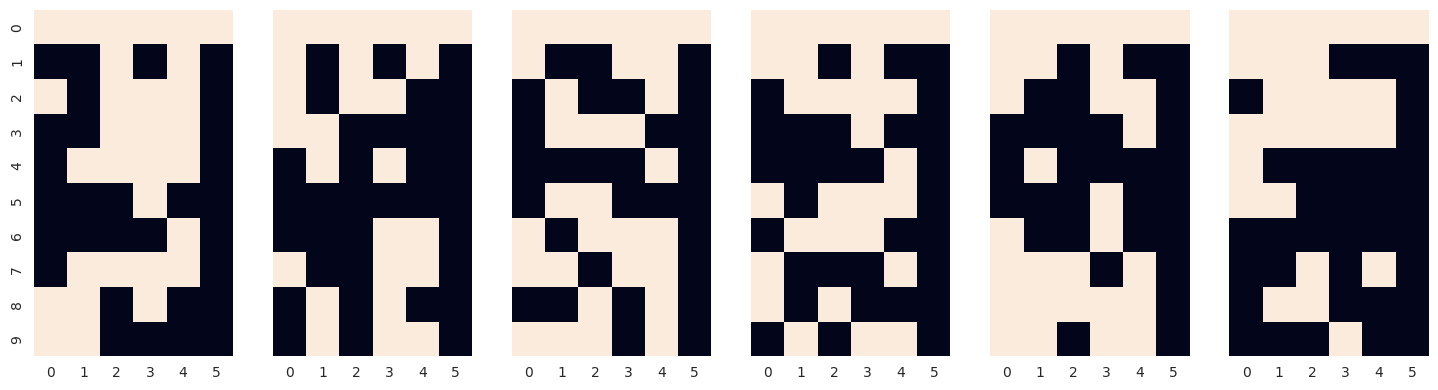

In [116]:
f, axes = plt.subplots(1, 6, figsize=(18, 4.5), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    sns.heatmap(samples['param_mask'][i], ax=ax, cbar=False, cmap="")

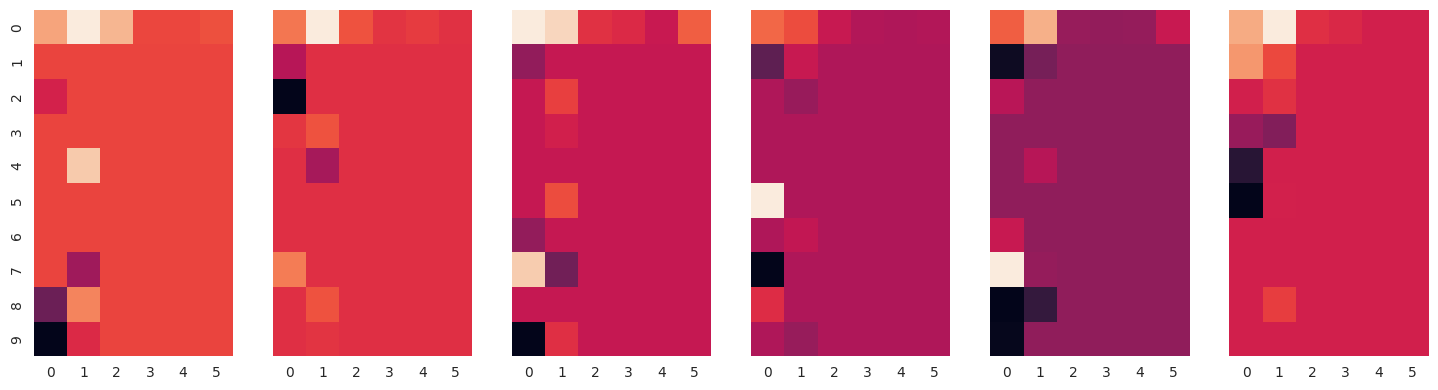

In [117]:
f, axes = plt.subplots(1, 6, figsize=(18, 4.5), sharey=True, sharex=True)

for i, ax in enumerate(axes):
    sns.heatmap(samples['param_matrices'][i], ax=ax, cbar=False)

### RDM

In [129]:
rdm_context = ContextManager()

In [130]:
rdm_intrinsics = ["v", "a", "tau", "decay"]

In [131]:
rdm_family = NestedModelFamily(
    name="rdm",
    model=RDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=rdm_intrinsics,
)

In [133]:
num_alternatives = np.random.randint(2, 4)
correct_idx = np.random.randint(0, num_alternatives, num_obs)
print(num_alternatives, correct_idx)

3 [1 2 1 ... 1 0 1]


In [134]:
context = {
    "num_alternatives": num_alternatives,
    "correct_idx": correct_idx
}

In [137]:
out = rdm_family.sample(
    design_config=None,
    num_obs=num_obs,
    num_regressors=num_regressors,
    context=context,
)

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
Unknown attribute 'shape' of type float32

File "../simulators/benchmarks/rdms/rdm.py", line 16:
def sample_rdm_trial(
    <source elided>
    # Infer number of alternatives
    num_alternatives = v.shape[0]
    ^

During: typing of get attribute at /home/a_huangm13/Documents/Research/Projects/BayesGPT/bayesgpt/simulators/benchmarks/rdms/rdm.py (16)

File "../simulators/benchmarks/rdms/rdm.py", line 16:
def sample_rdm_trial(
    <source elided>
    # Infer number of alternatives
    num_alternatives = v.shape[0]
    ^

During: Pass nopython_type_inference
During: resolving callee type: type(CPUDispatcher(<function sample_rdm_trial at 0x7012a84f7920>))
During: typing of call at /home/a_huangm13/Documents/Research/Projects/BayesGPT/bayesgpt/simulators/benchmarks/rdms/rdm.py (45)

During: resolving callee type: type(CPUDispatcher(<function sample_rdm_trial at 

In [123]:
cdm_family = NestedModelFamily(
    name="cdm",
    model=CDM(),
    context_manager=cm,
    prior_fun=priors,
    intrinsic_params=intrinsic_params,
)

In [124]:
out = cdm_family.sample(
    design_config=None,
    num_obs=num_obs,
    num_regressors=num_regressors,
    mask_randomizer_kwargs=dict(
        mandatory_intrinsics={"v", "a"},
        intercept_only_intrinsics={"tau", "s_tau", "s_v", "decay"},  # different mask each run, reproducible
    )
)

TypeError: too many arguments: expected 7, got 8